In [1]:
!pip install keras

In [2]:
from keras.layers import Dense, MaxPooling2D
from keras.models import Sequential
from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


/Users/valentinionescu/Downloads/MSIT/Computer_Vision_Lectures/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Data load
(train_imgs, train_labels),(test_imgs, test_labels)=mnist.load_data()

In [4]:
# Data Checkout
print ("The number of training examples is: ", train_imgs.shape[0])
print ("The number of test examples is: ", test_imgs.shape[0])
print ("The size of every img is: ", train_imgs.shape[1:])
num_classes=len(np.unique(train_labels))
print ("The number of classes is: ", num_classes)

The number of training examples is:  60000
The number of test examples is:  10000
The size of every img is:  (28, 28)
The number of classes is:  10


Text(0.5, 1.0, 'Ground truth is: 4')

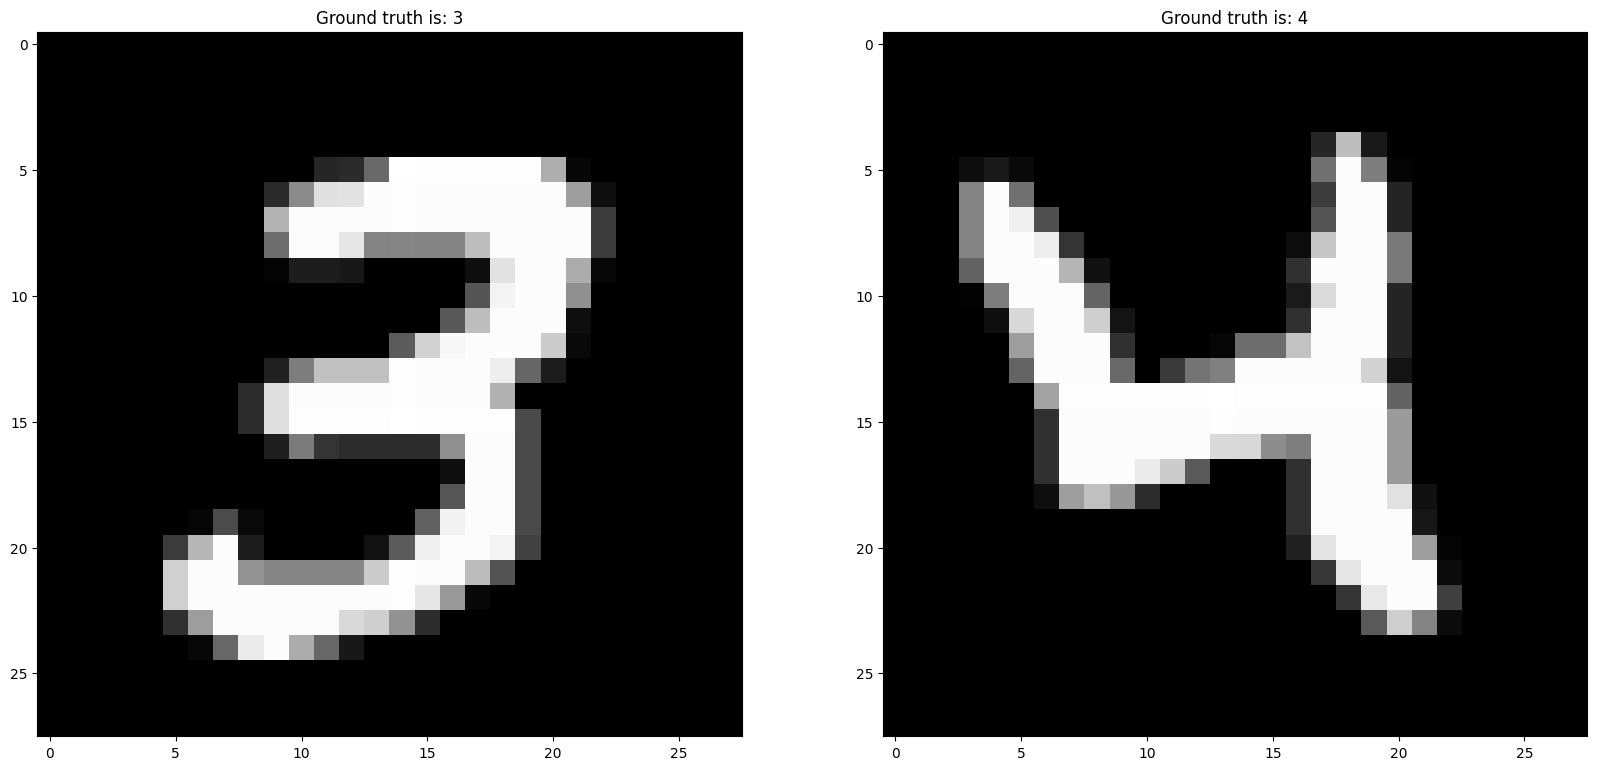

In [5]:
# printing out some samples
figure,(ax1,ax2)=plt.subplots(1,2,figsize=(20,10))

ax1.imshow(train_imgs[7,:,:],cmap='gray')
ax1.set_title("Ground truth is: {}".format(train_labels[7]))

ax2.imshow(train_imgs[20,:,:],cmap='gray')
ax2.set_title("Ground truth is: {}".format(train_labels[20]))

In [6]:
# Reshaping the input to be a vector instead of an array
dim_array=np.prod(train_imgs.shape[1:])
train_data=train_imgs.reshape(train_imgs.shape[0],dim_array)
test_data=test_imgs.reshape(test_imgs.shape[0],dim_array)

In [7]:
# Convert images to png (scale from 0 to 1)
train_data=train_data.astype('float32')
test_data=test_data.astype('float32')

train_data/=255
test_data/=255

In [8]:
#Converting labels to one-hot encoding form
from tensorflow.keras.utils import to_categorical

train_labels_one_hot=to_categorical(train_labels)
test_labels_one_hot=to_categorical(test_labels)

In [9]:
print("Before encoding",train_labels[5])
print("After encoding",train_labels_one_hot[5])

Before encoding 2
After encoding [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
#Create a network

model=Sequential()
model.add(Dense(512,activation='sigmoid',input_shape=(dim_array,)))
model.add(Dense(512,activation='sigmoid'))
model.add(Dense(num_classes,activation='softmax'))

/Users/valentinionescu/Downloads/MSIT/Computer_Vision_Lectures/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Configure a network
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
# train a model
history = model.fit(train_data, train_labels_one_hot, batch_size=256, epochs=20, verbose=1,
                   validation_data=(test_data, test_labels_one_hot))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5876 - loss: 1.3278 - val_accuracy: 0.8957 - val_loss: 0.3469
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8996 - loss: 0.3351 - val_accuracy: 0.9106 - val_loss: 0.2878
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9195 - loss: 0.2699 - val_accuracy: 0.9256 - val_loss: 0.2447
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9320 - loss: 0.2304 - val_accuracy: 0.9347 - val_loss: 0.2089
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9415 - loss: 0.1942 - val_accuracy: 0.9442 - val_loss: 0.1875
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9498 - loss: 0.1698 - val_accuracy: 0.9501 - val_loss: 0.1660
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9556 - loss: 0.1503 - val_accuracy: 0.9582 - val_loss: 0.1331
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9621 - loss: 0.1287 - val_accuracy: 0.

In [13]:
# test
[test_loss, test_acc] = model.evaluate(test_data, test_labels_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.9755 - loss: 0.0798
Evaluation result on Test Data : Loss = 0.06718797236680984, accuracy = 0.9799000024795532


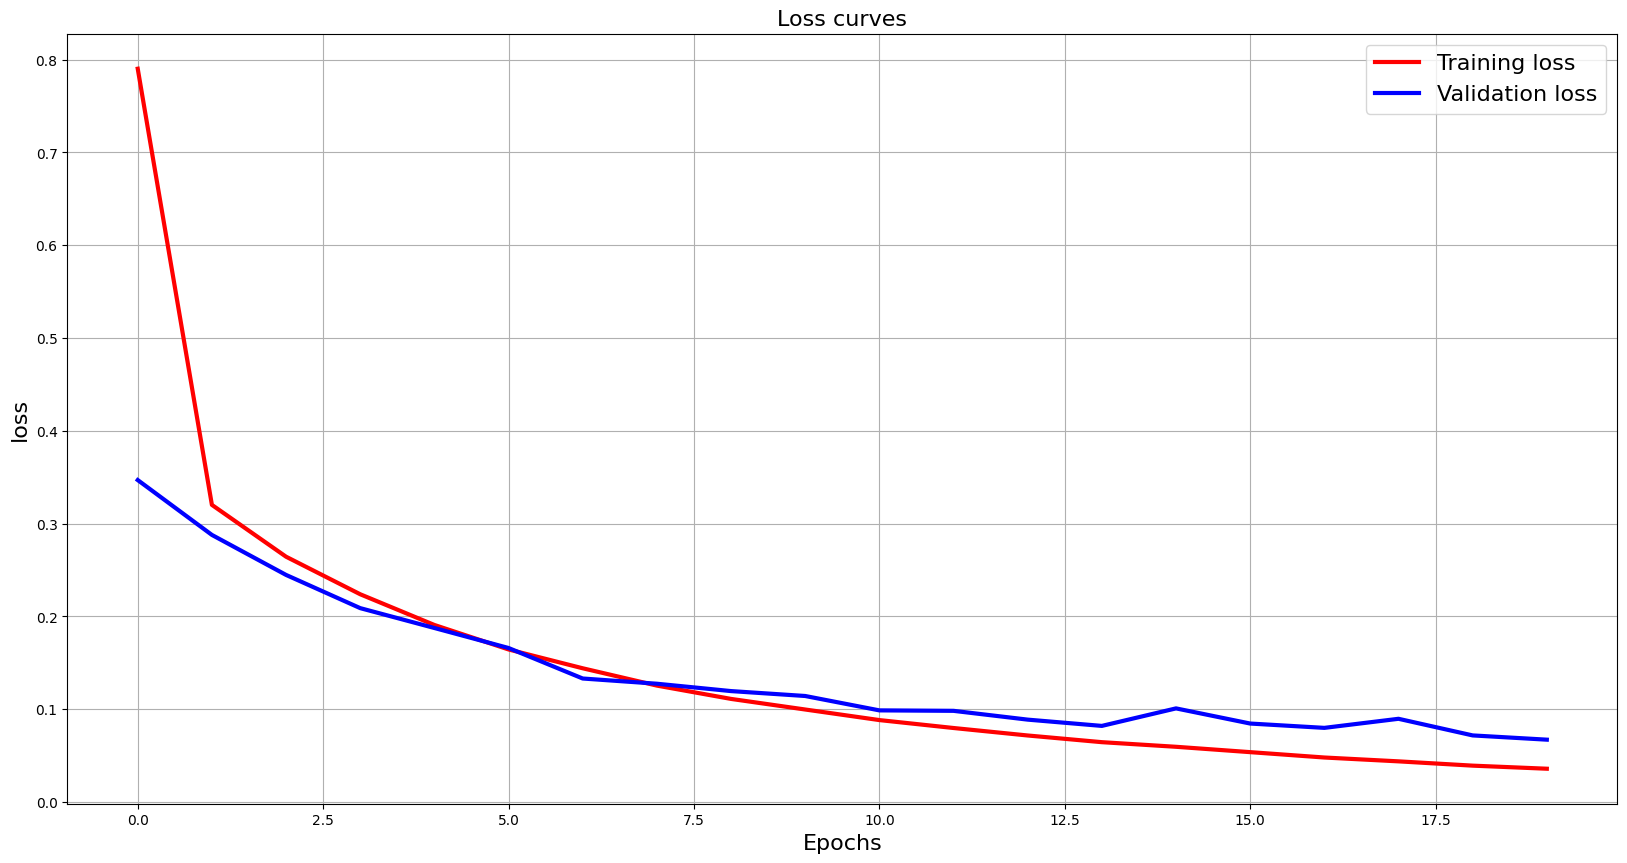

In [14]:
plt.figure(figsize=[20,10])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss','Validation loss'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('loss',fontsize=16)
plt.title('Loss curves',fontsize=16)
plt.grid()

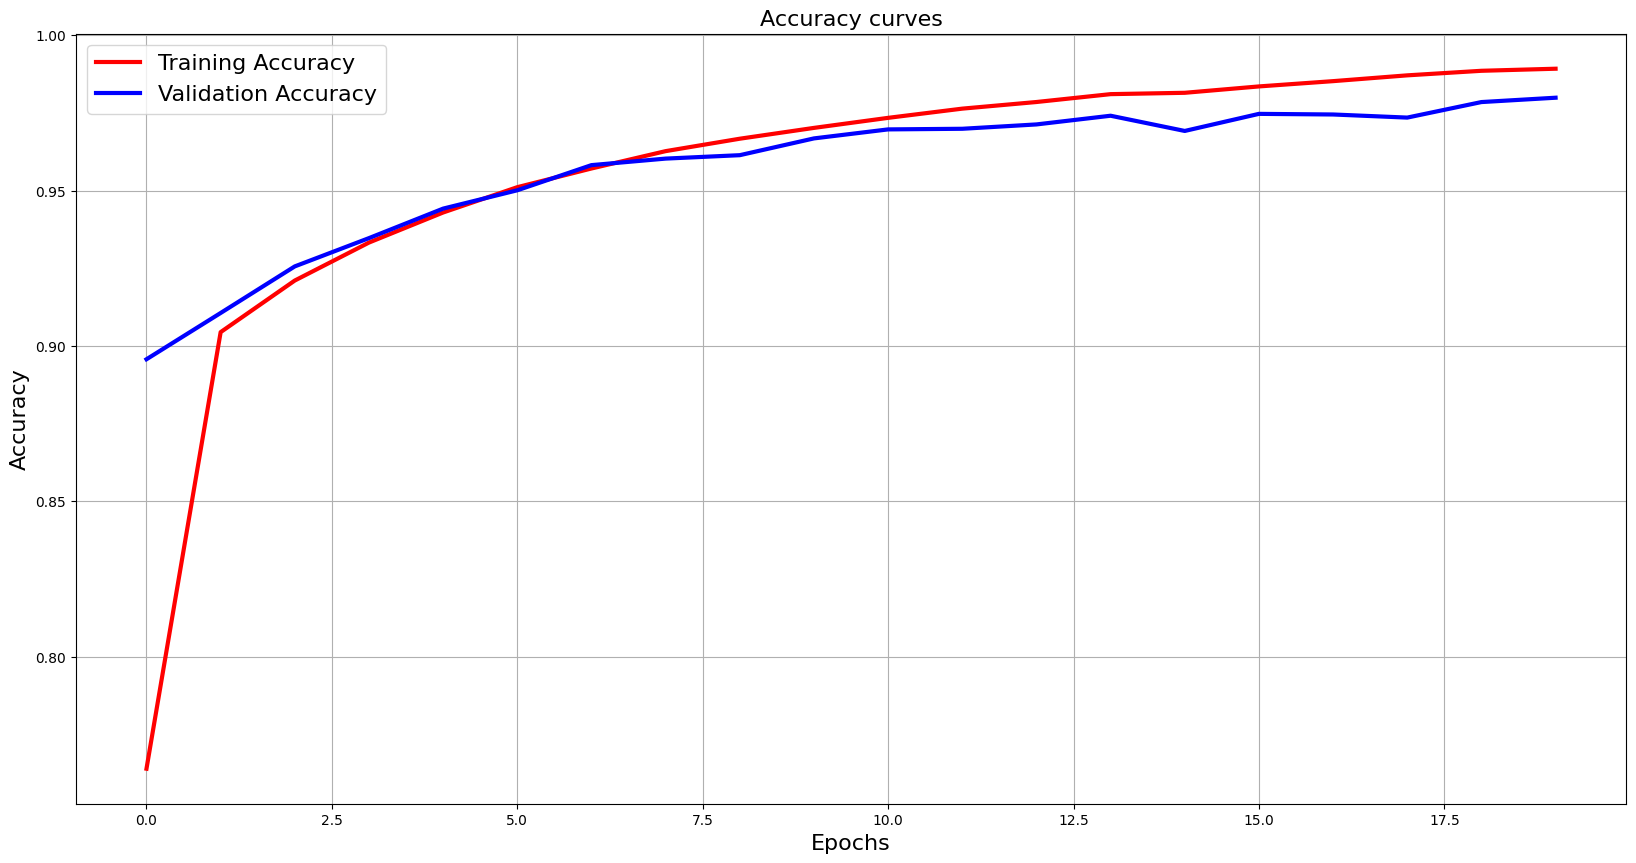

In [15]:
plt.figure(figsize=[20,10])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy','Validation Accuracy'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy curves',fontsize=16)
plt.grid()


In [16]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [17]:
# Check how dropout will affect validation accuracy

from keras.layers import Dropout, Input

model=Sequential()
model.add(Dense(512,activation='sigmoid',input_shape=[dim_array,]))
model.add(Dropout(0.5))
model.add(Dense(512,activation='sigmoid'))
model.add(Dropout(0.5))
model.add(Dense(num_classes,activation='softmax'))

In [18]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


In [19]:
history = model.fit(train_data, train_labels_one_hot, batch_size=256, epochs=20, verbose=1,
                   validation_data=(test_data, test_labels_one_hot))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4824 - loss: 1.5301 - val_accuracy: 0.8851 - val_loss: 0.3767
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8659 - loss: 0.4378 - val_accuracy: 0.9162 - val_loss: 0.2816
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8944 - loss: 0.3526 - val_accuracy: 0.9277 - val_loss: 0.2433
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9083 - loss: 0.2984 - val_accuracy: 0.9366 - val_loss: 0.2115
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9189 - loss: 0.2647 - val_accuracy: 0.9430 - val_loss: 0.1870
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9274 - loss: 0.2331 - val_accuracy: 0.9491 - val_loss: 0.1663
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9348 - loss: 0.2159 - val_accuracy: 0.9530 - val_loss: 0.1550
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9403 - loss: 0.1961 - val_accuracy: 0.

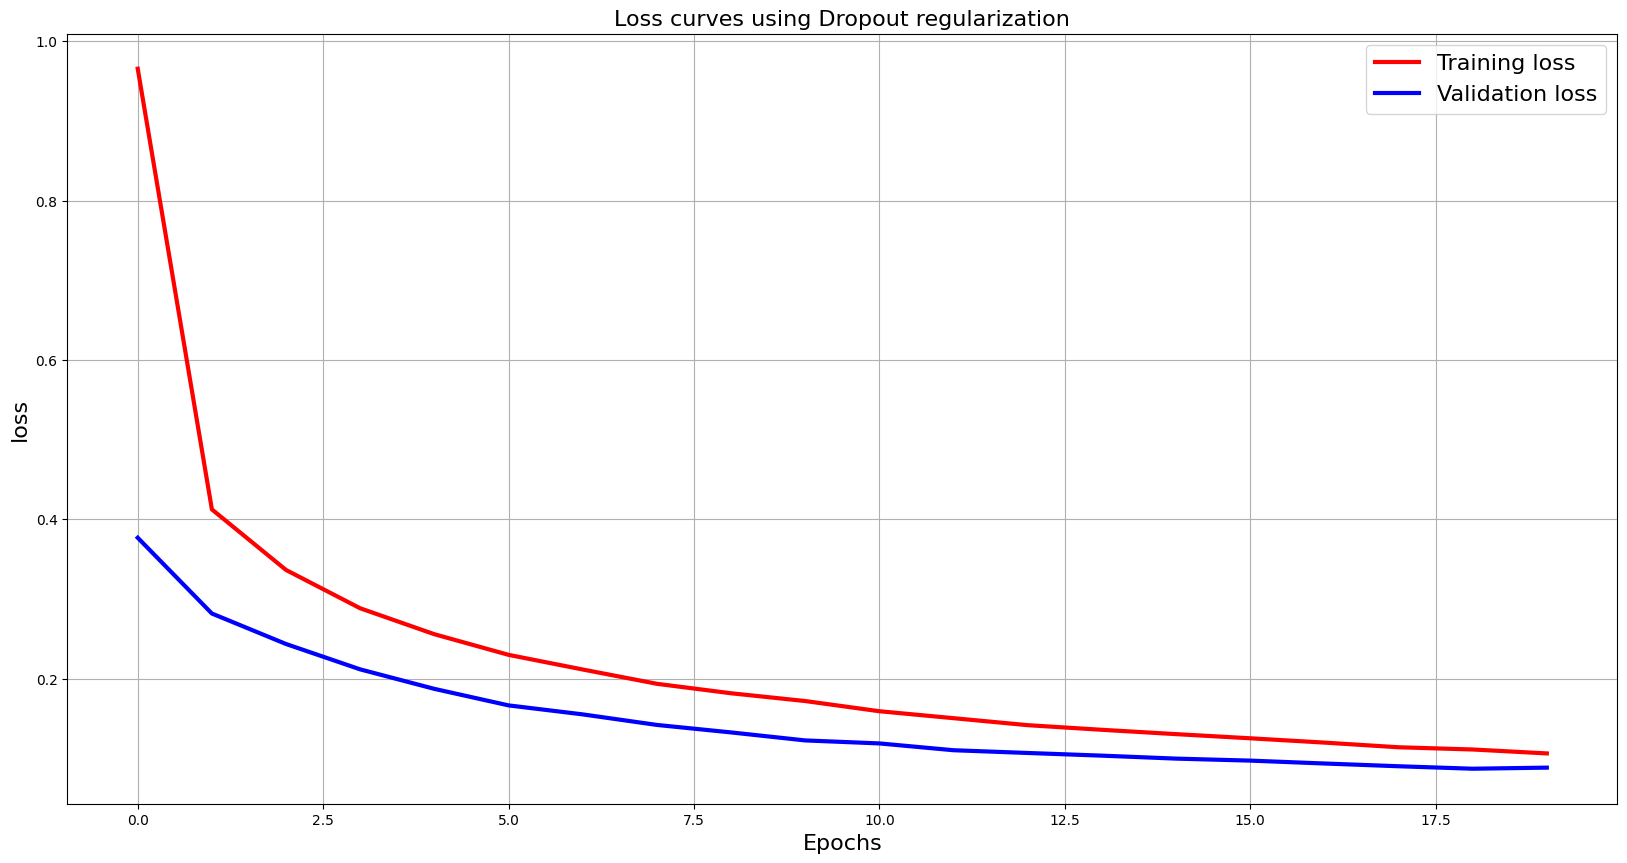

In [20]:
plt.figure(figsize=[20,10])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss','Validation loss'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('loss',fontsize=16)
plt.title('Loss curves using Dropout regularization',fontsize=16)
plt.grid()

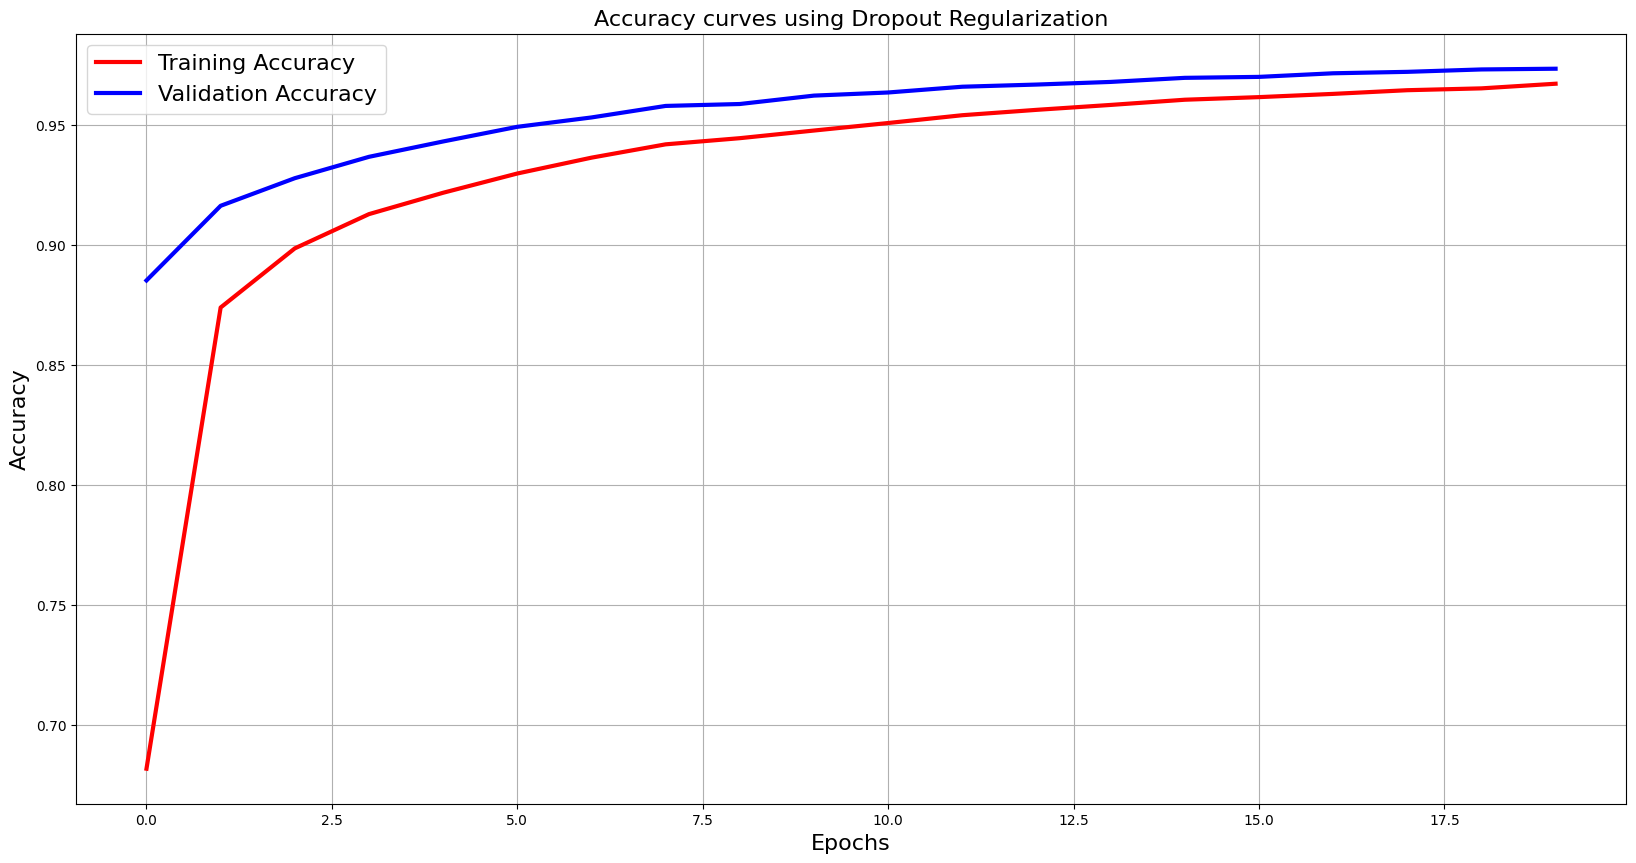

In [21]:
plt.figure(figsize=[20,10])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy','Validation Accuracy'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy curves using Dropout Regularization',fontsize=16)
plt.grid()

In [ ]:
model.predict(test_data[[8],:])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[2.1804939e-04, 3.1244706e-06, 7.8654622e-05, 1.5042014e-06,
        2.4199388e-03, 2.5364420e-01, 7.4102443e-01, 4.8408584e-08,
        1.2721001e-03, 1.3378868e-03]], dtype=float32)

In [36]:
np.argmax(model.predict(test_data[[0],:]))
print(train_labels[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5


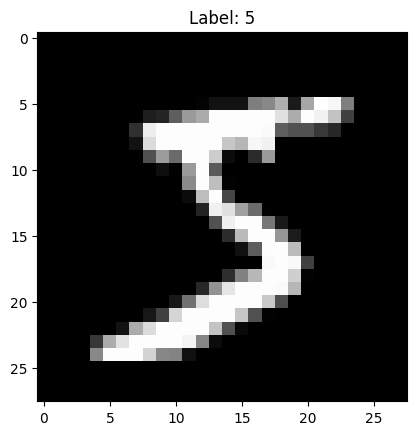

In [34]:
plt.imshow(train_imgs[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

In [ ]:
tst = model.predict(test_data)
print(tst)
preds = np.argmax(tst, axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1.0570326e-06 1.1258601e-06 1.5346814e-04 ... 9.9962342e-01
  6.6149875e-07 1.9088428e-05]
 [1.2792973e-06 2.1850734e-04 9.9929160e-01 ... 7.0153940e-09
  7.3233969e-06 8.0157781e-12]
 [5.7223139e-07 9.9766964e-01 2.9750675e-04 ... 9.7741280e-04
  8.0271839e-04 7.3256788e-06]
 ...
 [4.6544796e-10 4.5716617e-09 1.3967527e-10 ... 2.2683011e-05
  5.6327590e-06 3.3112496e-04]
 [1.3178134e-05 7.8069553e-07 1.8805265e-08 ... 6.3295352e-07
  5.1088678e-04 8.3709338e-08]
 [1.6628581e-05 1.6085133e-08 9.2138871e-06 ... 1.8271492e-09
  2.5283049e-07 6.8499489e-08]]


array([7, 2, 1, ..., 4, 5, 6])

In [ ]:
one_data_point_slice_8 = model.predict(test_data[[8],:])